In [34]:
# Cell 1: Import libraries

from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully. ✅")

Libraries imported successfully. ✅


In [35]:
# Cell 2: Reproducibility

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [36]:
# Cell 3: Project paths

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishing_features.csv"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

RF_MODEL_PATH = (
    MODEL_DIR
    / "random_forest.joblib"
)

ANN_MODEL_PATH = (
    MODEL_DIR
    / "ann_model.pth"
)

ANN_SCALER_PATH = (
    MODEL_DIR
    / "ann_scaler.joblib"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset:")
print(DATA_PATH)

print("\nRandom Forest:")
print(RF_MODEL_PATH)

print("\nANN:")
print(ANN_MODEL_PATH)

Project root:
c:\Users\Manid\project1

Dataset:
c:\Users\Manid\project1\data\processed\phishing_features.csv

Random Forest:
c:\Users\Manid\project1\models\random_forest.joblib

ANN:
c:\Users\Manid\project1\models\ann_model.pth


In [37]:
# Cell 4: Create results directory

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Results directory ready. ✅"
)

print(
    RESULTS_DIR
)

Results directory ready. ✅
c:\Users\Manid\project1\results


In [38]:
# Cell 5: Verify required files

required_files = {
    "Feature dataset": DATA_PATH,
    "Random Forest": RF_MODEL_PATH,
    "ANN model": ANN_MODEL_PATH,
    "ANN scaler": ANN_SCALER_PATH
}

for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    if path.stat().st_size == 0:

        raise ValueError(
            f"{name} exists but is empty:\n{path}"
        )

    print(
        f"✓ {name}: "
        f"{path.stat().st_size:,} bytes"
    )

print("\nAll required files verified. ✅")

✓ Feature dataset: 16,157,436 bytes
✓ Random Forest: 59,324,393 bytes
✓ ANN model: 63,756 bytes
✓ ANN scaler: 1,775 bytes

All required files verified. ✅


In [39]:
# Cell 6: Load feature dataset

df = pd.read_csv(
    DATA_PATH
)

print(
    "Dataset loaded successfully. ✅"
)

print(
    "Shape:",
    df.shape
)

display(
    df.head()
)

Dataset loaded successfully. ✅
Shape: (235795, 24)


,url_length,dot_count,hyphen_count,underscore_count,slash_count,digit_count,letter_count,special_character_count,has_https,has_http,...,has_query,has_fragment,has_percent_encoding,has_suspicious_double_slash,hostname_length,subdomain_count,hostname_digit_count,hostname_hyphen_count,suspicious_tld,label
0,32,2,0,0,2,0,27,5,1,0,...,0,0,0,0,24,1,0,0,0,1
1,24,2,1,0,2,0,18,6,1,0,...,0,0,0,0,16,1,0,1,0,1
2,30,3,0,0,2,0,24,6,1,0,...,0,0,0,0,22,2,0,0,0,1
3,27,2,0,0,2,0,22,5,1,0,...,0,0,0,0,19,1,0,0,0,1
4,34,2,0,0,2,0,29,5,1,0,...,0,0,0,0,26,1,0,0,0,1


In [40]:
# Cell 7: Separate features and target

TARGET_COLUMN = "label"

if TARGET_COLUMN not in df.columns:

    raise ValueError(
        "Column 'label' not found."
    )

X = df.drop(
    columns=[TARGET_COLUMN]
)

y = df[TARGET_COLUMN]

print(
    "Feature count:",
    X.shape[1]
)

print(
    "Target values:",
    sorted(y.unique())
)

Feature count: 23
Target values: [np.int64(0), np.int64(1)]


In [41]:
# Cell 8: Recreate identical train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Identical train/test split created. ✅")

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Identical train/test split created. ✅
Training samples: 188636
Testing samples: 47159


In [42]:
# Cell 9: Verify feature count

EXPECTED_FEATURES = 23

if X.shape[1] != EXPECTED_FEATURES:

    raise ValueError(
        f"Expected {EXPECTED_FEATURES} features, "
        f"but found {X.shape[1]}."
    )

print(
    f"Feature count verified: "
    f"{X.shape[1]} ✅"
)

Feature count verified: 23 ✅


In [43]:
# Cell 10: Load Random Forest

rf_model = joblib.load(
    RF_MODEL_PATH
)

print(
    "Random Forest loaded successfully. ✅"
)

print(
    "Number of trees:",
    rf_model.n_estimators
)

print(
    "Number of features:",
    rf_model.n_features_in_
)

Random Forest loaded successfully. ✅
Number of trees: 300
Number of features: 23


In [44]:
# Cell 11: Random Forest predictions

rf_predictions = rf_model.predict(
    X_test
)

rf_probabilities = rf_model.predict_proba(
    X_test
)

print(
    "Random Forest predictions generated. ✅"
)

print(
    "Prediction shape:",
    rf_predictions.shape
)

print(
    "Probability shape:",
    rf_probabilities.shape
)

Random Forest predictions generated. ✅
Prediction shape: (47159,)
Probability shape: (47159, 2)


In [45]:
# Cell 12: Define ANN architecture

class PhishGuardANN(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_size,
                128
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(
                128,
                64
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.Dropout(0.20),

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                1
            )
        )

    def forward(self, x):

        return self.network(x).squeeze(1)


print(
    "ANN architecture defined. ✅"
)

ANN architecture defined. ✅


In [46]:
# Cell 13: Select PyTorch device

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    DEVICE
)

Device: cuda


In [47]:
# Cell 14: Load ANN scaler

ann_scaler = joblib.load(
    ANN_SCALER_PATH
)

print(
    "ANN scaler loaded successfully. ✅"
)

ANN scaler loaded successfully. ✅


In [48]:
# Cell 15: Prepare ANN test features

X_test_ann = ann_scaler.transform(
    X_test
)

X_test_ann = X_test_ann.astype(
    np.float32
)

print(
    "ANN test features prepared. ✅"
)

print(
    "Shape:",
    X_test_ann.shape
)

ANN test features prepared. ✅
Shape: (47159, 23)


In [49]:
# Cell 16: Load saved ANN

ann_checkpoint = torch.load(
    ANN_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)

ann_input_size = (
    ann_checkpoint["input_size"]
)

if ann_input_size != X_test_ann.shape[1]:

    raise ValueError(
        "ANN input size does not match "
        "the feature dataset."
    )

ann_model = PhishGuardANN(
    ann_input_size
).to(DEVICE)

ann_model.load_state_dict(
    ann_checkpoint["model_state_dict"]
)

ann_model.eval()

print(
    "ANN loaded successfully. ✅"
)

print(
    "ANN input features:",
    ann_input_size
)

ANN loaded successfully. ✅
ANN input features: 23


In [50]:
# Cell 17: Generate ANN predictions

X_test_tensor = torch.tensor(
    X_test_ann,
    dtype=torch.float32
).to(DEVICE)

with torch.no_grad():

    ann_logits = ann_model(
        X_test_tensor
    )

    ann_probabilities_class_1 = (
        torch.sigmoid(
            ann_logits
        )
        .cpu()
        .numpy()
    )

ann_predictions = (
    ann_probabilities_class_1 >= 0.5
).astype(
    np.int64
)

print(
    "ANN predictions generated. ✅"
)

print(
    "Prediction shape:",
    ann_predictions.shape
)

ANN predictions generated. ✅
Prediction shape: (47159,)


In [51]:
# Cell 18: Verify predictions

print(
    "Random Forest classes:",
    np.unique(rf_predictions)
)

print(
    "ANN classes:",
    np.unique(ann_predictions)
)

print(
    "\nRandom Forest first 10:",
    rf_predictions[:10]
)

print(
    "ANN first 10:",
    ann_predictions[:10]
)

Random Forest classes: [0 1]
ANN classes: [0 1]

Random Forest first 10: [1 1 1 1 1 0 1 1 1 0]
ANN first 10: [1 1 1 1 1 0 1 1 1 0]


In [52]:
# Cell 19: Evaluation function

def calculate_metrics(
    y_true,
    predictions,
    probabilities_class_1
):

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        pos_label=1,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities_class_1
    )

    phishing_recall = recall_score(
        y_true,
        predictions,
        pos_label=0,
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Phishing Recall": phishing_recall
    }


print(
    "Metric function created. ✅"
)

Metric function created. ✅


In [53]:
# Cell 20: Random Forest metrics

rf_metrics = calculate_metrics(
    y_test,
    rf_predictions,
    rf_probabilities[:, 1]
)

print(
    "Random Forest metrics calculated. ✅"
)

for metric, value in rf_metrics.items():

    print(
        f"{metric:<20}: "
        f"{value:.4f}"
    )

Random Forest metrics calculated. ✅
Accuracy            : 0.9950
Precision           : 0.9937
Recall              : 0.9976
F1-Score            : 0.9956
ROC-AUC             : 0.9968
Phishing Recall     : 0.9915


In [54]:
# Cell 21: ANN metrics

ann_metrics = calculate_metrics(
    y_test,
    ann_predictions,
    ann_probabilities_class_1
)

print(
    "ANN metrics calculated. ✅"
)

for metric, value in ann_metrics.items():

    print(
        f"{metric:<20}: "
        f"{value:.4f}"
    )

ANN metrics calculated. ✅
Accuracy            : 0.9958
Precision           : 0.9932
Recall              : 0.9995
F1-Score            : 0.9963
ROC-AUC             : 0.9982
Phishing Recall     : 0.9909


In [55]:
# Cell 22: Create comparison table

comparison_df = pd.DataFrame(
    {
        "Random Forest": rf_metrics,
        "ANN": ann_metrics
    }
).T

display(
    comparison_df.style.format(
        "{:.4f}"
    )
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Phishing Recall
Random Forest,0.9950,0.9937,0.9976,0.9956,0.9968,0.9915
ANN,0.9958,0.9932,0.9995,0.9963,0.9982,0.9909


In [56]:
# Cell 23: Percentage comparison

percentage_df = (
    comparison_df
    * 100
)

display(
    percentage_df.style.format(
        "{:.2f}%"
    )
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Phishing Recall
Random Forest,99.50%,99.37%,99.76%,99.56%,99.68%,99.15%
ANN,99.58%,99.32%,99.95%,99.63%,99.82%,99.09%


In [57]:
# Cell 24: Select best model

rf_phishing_recall = (
    rf_metrics["Phishing Recall"]
)

ann_phishing_recall = (
    ann_metrics["Phishing Recall"]
)

if rf_phishing_recall > ann_phishing_recall:

    best_model = "Random Forest"

elif ann_phishing_recall > rf_phishing_recall:

    best_model = "ANN"

else:

    best_model = "Tie"

print("=" * 60)

print(
    "SECURITY-FOCUSED MODEL SELECTION"
)

print("=" * 60)

print(
    f"Random Forest Phishing Recall: "
    f"{rf_phishing_recall * 100:.2f}%"
)

print(
    f"ANN Phishing Recall: "
    f"{ann_phishing_recall * 100:.2f}%"
)

print(
    f"\nSelected model: {best_model}"
)

SECURITY-FOCUSED MODEL SELECTION
Random Forest Phishing Recall: 99.15%
ANN Phishing Recall: 99.09%

Selected model: Random Forest


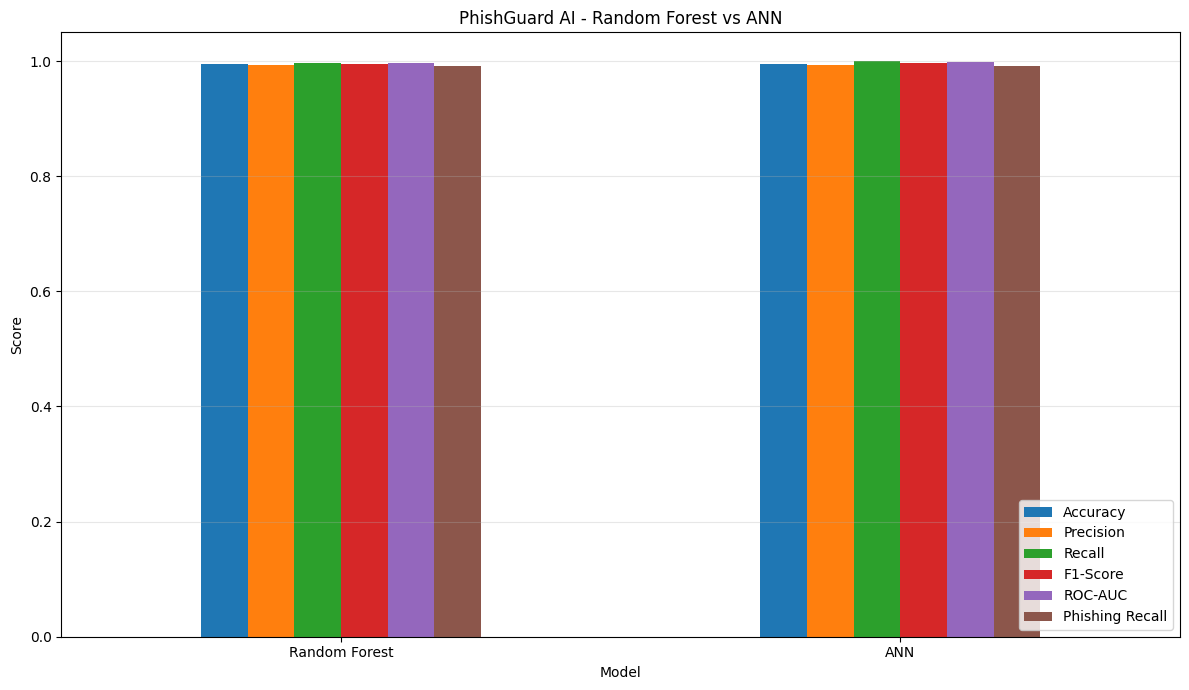

Chart saved to:
c:\Users\Manid\project1\results\model_comparison.png


In [58]:
# Cell 25: Model comparison chart

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Phishing Recall"
]

comparison_df[
    metrics_to_plot
].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "PhishGuard AI - Random Forest vs ANN"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

MODEL_COMPARISON_PATH = (
    RESULTS_DIR
    / "model_comparison.png"
)

plt.savefig(
    MODEL_COMPARISON_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Chart saved to:\n"
    f"{MODEL_COMPARISON_PATH}"
)

Random Forest confusion matrix:
[[20018   171]
 [   66 26904]]


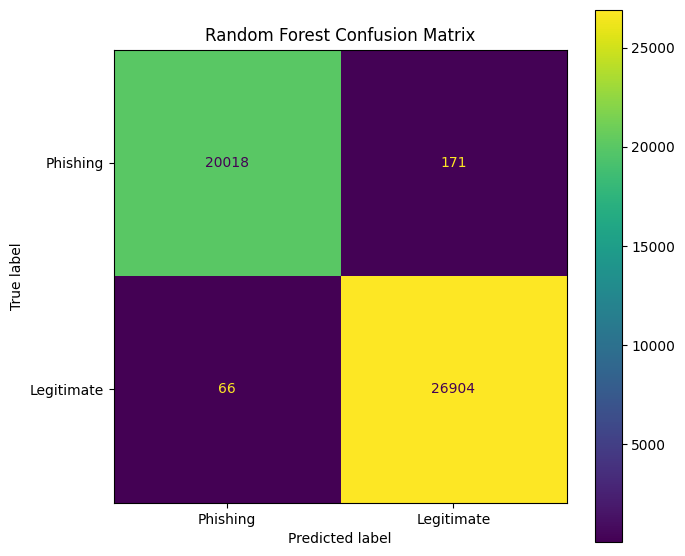

In [59]:
# Cell 26: Random Forest confusion matrix

rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=[0, 1]
)

print(
    "Random Forest confusion matrix:"
)

print(rf_cm)

rf_display = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

rf_display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Random Forest Confusion Matrix"
)

plt.tight_layout()

RF_CM_PATH = (
    RESULTS_DIR
    / "confusion_matrix_rf.png"
)

plt.savefig(
    RF_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ANN confusion matrix:
[[20005   184]
 [   14 26956]]


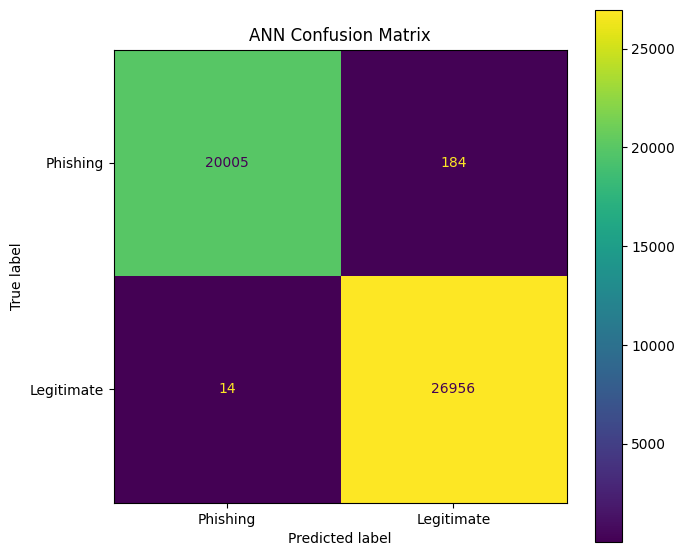

In [60]:
# Cell 27: ANN confusion matrix

ann_cm = confusion_matrix(
    y_test,
    ann_predictions,
    labels=[0, 1]
)

print(
    "ANN confusion matrix:"
)

print(ann_cm)

ann_display = ConfusionMatrixDisplay(
    confusion_matrix=ann_cm,
    display_labels=[
        "Phishing",
        "Legitimate"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ann_display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "ANN Confusion Matrix"
)

plt.tight_layout()

ANN_CM_PATH = (
    RESULTS_DIR
    / "confusion_matrix_ann.png"
)

plt.savefig(
    ANN_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
# Cell 28: Random Forest classification report

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Phishing",
            "Legitimate"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           0.99     47159
   macro avg       1.00      0.99      0.99     47159
weighted avg       0.99      0.99      0.99     47159



In [62]:
# Cell 29: ANN classification report

print(
    classification_report(
        y_test,
        ann_predictions,
        target_names=[
            "Phishing",
            "Legitimate"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [63]:
# Cell 30: Save comparison results

comparison_csv_path = (
    RESULTS_DIR
    / "model_comparison.csv"
)

comparison_df.to_csv(
    comparison_csv_path
)

print(
    "Comparison results saved. ✅"
)

print(
    comparison_csv_path
)

Comparison results saved. ✅
c:\Users\Manid\project1\results\model_comparison.csv


In [64]:
# Cell 31: Save model selection metadata

selection_data = {
    "selected_model": best_model,

    "selection_criterion": (
        "Highest phishing recall"
    ),

    "random_forest": {
        key: float(value)
        for key, value
        in rf_metrics.items()
    },

    "ann": {
        key: float(value)
        for key, value
        in ann_metrics.items()
    }
}

selection_path = (
    RESULTS_DIR
    / "model_selection.json"
)

with open(
    selection_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        selection_data,
        file,
        indent=4
    )

print(
    "Model selection saved. ✅"
)

print(
    selection_path
)

Model selection saved. ✅
c:\Users\Manid\project1\results\model_selection.json


In [65]:
# Cell 32: Final summary

print("=" * 70)
print("PHISHGUARD AI - MODEL COMPARISON COMPLETE")
print("=" * 70)

print("\nRandom Forest")
print("-" * 70)

for metric, value in rf_metrics.items():

    print(
        f"{metric:<20}: "
        f"{value * 100:.2f}%"
    )

print("\nANN")
print("-" * 70)

for metric, value in ann_metrics.items():

    print(
        f"{metric:<20}: "
        f"{value * 100:.2f}%"
    )

print("\n" + "=" * 70)

print(
    f"SELECTED MODEL: {best_model}"
)

print("=" * 70)

print("\nGenerated result files:")

print("✓ model_comparison.png")
print("✓ model_comparison.csv")
print("✓ confusion_matrix_rf.png")
print("✓ confusion_matrix_ann.png")
print("✓ model_selection.json")

PHISHGUARD AI - MODEL COMPARISON COMPLETE

Random Forest
----------------------------------------------------------------------
Accuracy            : 99.50%
Precision           : 99.37%
Recall              : 99.76%
F1-Score            : 99.56%
ROC-AUC             : 99.68%
Phishing Recall     : 99.15%

ANN
----------------------------------------------------------------------
Accuracy            : 99.58%
Precision           : 99.32%
Recall              : 99.95%
F1-Score            : 99.63%
ROC-AUC             : 99.82%
Phishing Recall     : 99.09%

SELECTED MODEL: Random Forest

Generated result files:
✓ model_comparison.png
✓ model_comparison.csv
✓ confusion_matrix_rf.png
✓ confusion_matrix_ann.png
✓ model_selection.json
